# Ridge Regression (Baseline Performance)

## Setup

In [1]:
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error, mean_squared_error , r2_score

from sklearn.linear_model import Ridge


In [2]:
# Load arrays from the compressed archive
data = np.load('datasets/processed_splits.npz')

X_tr_scaled = data['X_tr']
y_tr_scaled = data['y_tr_scaled']
y_tr = data['y_tr']
X_val_scaled = data['X_val']
y_val = data['y_val']

# import exact scaler instance from the preprocessing notebook
target_scaler = joblib.load('datasets/target_scaler.joblib')
print('All data successfully imported.')


All data successfully imported.


## Training

In [3]:
alpha_values = [0.01, 0.1, 1, 2, 3, 4, 5, 10, 20]

# initialize arrays to store rmse and r2 scores for [kappa, beta]
rmse_scores = np.zeros((len(alpha_values), 2))
r2_scores = np.zeros((len(alpha_values), 2))

# grid search loop to find optimal alpha
for i, alpha in enumerate(alpha_values):
    # intialize model and fit
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X_tr_scaled, y_tr_scaled)

    # make predictions using scaled targets and undo scaling
    y_pred_scaled = ridge_model.predict(X_val_scaled)
    y_pred_unscaled = target_scaler.inverse_transform(y_pred_scaled)

    # compute rmse for kappa and beta
    kappa_rmse = root_mean_squared_error(y_val[:,0], y_pred_unscaled[:,0])
    beta_rmse = root_mean_squared_error(y_val[:,1], y_pred_unscaled[:,1])

    # compute r2 for kappa and beta
    kappa_r2 = r2_score(y_val[:,0], y_pred_unscaled[:,0])
    beta_r2 = r2_score(y_val[:,1], y_pred_unscaled[:,1])

    # store meetrics
    rmse_scores[i,0] = kappa_rmse
    rmse_scores[i,1] = beta_rmse

    r2_scores[i,0] = kappa_r2
    r2_scores[i,1] = beta_r2


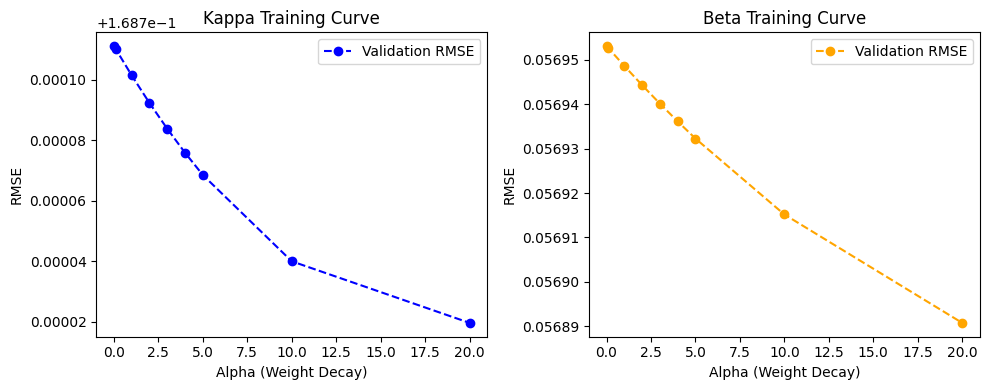

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# plot kappa training curve
ax1.plot(alpha_values, rmse_scores[:,0], linestyle='--', marker='o', color='blue', label='Validation RMSE')
ax1.set_title('Kappa Training Curve')
ax1.set_ylabel('RMSE')
ax1.set_xlabel('Alpha (Weight Decay)')
ax1.legend()

# plot beta training curve
ax2.plot(alpha_values, rmse_scores[:,1], linestyle='--', marker='o', color='orange', label='Validation RMSE')
ax2.set_title('Beta Training Curve')
ax2.set_ylabel('RMSE')
ax2.set_xlabel('Alpha (Weight Decay)')
ax2.legend()

plt.tight_layout()
plt.show()

In [5]:
# extract the optimally performing value of alpha from training by creating a mean of the r2 scores of kappa and beta for each alpha instance

mean_r2_scores = r2_scores.mean(axis=1)

best_score_index = np.argmax(mean_r2_scores)

best_ridge_score_alpha = alpha_values[best_score_index]

print('The best performing alpha regularization parameter was found to be alpha =', best_ridge_score_alpha)
print(f'Alpha = {best_ridge_score_alpha} had a RMSE of {rmse_scores[best_score_index, 0]:.3f} for kappa and {rmse_scores[best_score_index, 1]:.3f} for beta')


The best performing alpha regularization parameter was found to be alpha = 20
Alpha = 20 had a RMSE of 0.169 for kappa and 0.057 for beta


## Final Model

In [6]:
# intialize model and fit to training data using optimal alpha value
ridge_model = Ridge(alpha=best_ridge_score_alpha)
ridge_model.fit(X_tr_scaled, y_tr_scaled)

# make predictions on training and validation sets and undo scaling on targets
y_pred_ridge_tr_scaled = ridge_model.predict(X_tr_scaled)
y_pred_ridge_scaled = ridge_model.predict(X_val_scaled)
y_pred_ridge_tr = target_scaler.inverse_transform(y_pred_ridge_tr_scaled)
y_pred_ridge = target_scaler.inverse_transform(y_pred_ridge_scaled)


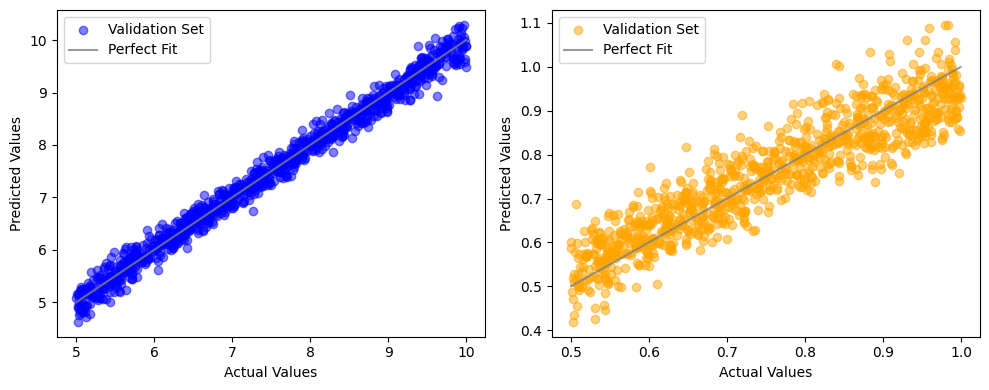

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))

# plot kappa predictions using optimal Ridge regression model
ax1.scatter(y_val[:,0], y_pred_ridge[:,0], color='blue', alpha=0.5, label='Validation Set')
# generate line of perfect fit (y=x)
ideal_line_kappa = np.linspace(min(y_val[:,0]), max(y_val[:,0]), 100)
ax1.plot(ideal_line_kappa, ideal_line_kappa, color='grey', alpha=0.8, label='Perfect Fit')

ax1.set_xlabel('Actual Values')
ax1.set_ylabel('Predicted Values')
ax1.legend()

# plot beta predictions using optimal Ridge regression model
ax2.scatter(y_val[:,1], y_pred_ridge[:,1], color='orange', alpha=0.5, label='Validation Set')
# generate line of perfect fit (y=x)
ideal_line_beta = np.linspace(min(y_val[:,1]), max(y_val[:,1]), 100)
ax2.plot(ideal_line_beta, ideal_line_beta, color='grey', alpha=0.8, label='Perfect Fit')

ax2.set_xlabel('Actual Values')
ax2.set_ylabel('Predicted Values')
ax2.legend()

plt.tight_layout()
plt.show()


In [8]:
# Ridge regression quantification metrics

# validation set
ridge_kappa_rmse_val = root_mean_squared_error(y_val[:,0], y_pred_ridge[:,0])
ridge_kappa_mse_val = mean_squared_error(y_val[:,0], y_pred_ridge[:,0])
ridge_kappa_r2_val = r2_score(y_val[:,0], y_pred_ridge[:,0])

ridge_beta_rmse_val = root_mean_squared_error(y_val[:,1], y_pred_ridge[:,1])
ridge_beta_mse_val = mean_squared_error(y_val[:,1], y_pred_ridge[:,1])
ridge_beta_r2_val = r2_score(y_val[:,1], y_pred_ridge[:,1])

# training set
ridge_kappa_rmse_tr = root_mean_squared_error(y_tr[:,0], y_pred_ridge_tr[:,0])
ridge_kappa_mse_tr = mean_squared_error(y_tr[:,0], y_pred_ridge_tr[:,0])
ridge_kappa_r2_tr = r2_score(y_tr[:,0], y_pred_ridge_tr[:,0])

ridge_beta_rmse_tr = root_mean_squared_error(y_tr[:,1], y_pred_ridge_tr[:,1])
ridge_beta_mse_tr = mean_squared_error(y_tr[:,1], y_pred_ridge_tr[:,1])
ridge_beta_r2_tr = r2_score(y_tr[:,1], y_pred_ridge_tr[:,1])

print('\nKappa | Training | Validation')
print('-------------------------------')
print(f'RMSE: {ridge_kappa_rmse_tr:.3f} | {ridge_kappa_rmse_val:.3f}')
print(f'MSE: {ridge_kappa_mse_tr:.3f} | {ridge_kappa_mse_val:.3f}')
print(f'R^2: {ridge_kappa_r2_tr:.3f} | {ridge_kappa_r2_val:.3f}')

print('\nBeta | Training | Validation')
print('-------------------------------')
print(f'RMSE | {ridge_beta_rmse_tr:.3f} | {ridge_beta_rmse_val:.3f}')
print(f'MSE | {ridge_beta_mse_tr:.3f} | {ridge_beta_mse_val:.3f}')
print(f'R^2 | {ridge_beta_r2_tr:.3f} | {ridge_beta_r2_val:.3f}')



Kappa | Training | Validation
-------------------------------
RMSE: 0.163 | 0.169
MSE: 0.026 | 0.028
R^2: 0.987 | 0.986

Beta | Training | Validation
-------------------------------
RMSE | 0.055 | 0.057
MSE | 0.003 | 0.003
R^2 | 0.856 | 0.850


Save the optimized Ridge Regression model for comparison with other models

In [11]:
joblib.dump(ridge_model, 'models/ridge_model.joblib')
print('Optimal Ridge model saved')


Optimal Ridge model saved
